<a href="https://colab.research.google.com/github/sivananda-gif/used-car-price-prediction/blob/main/sivananda_used_car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
import pandas as pd
ds=pd.read_csv('/content/drive/MyDrive/AI & ML/used_car_price_prediction_1M.csv')
ds

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06
1004996,Honda,Amaze,2005,NaN,1705.773023,99.643689,CNG,Automatic,First,NaN,Pune,311400,1,1,0,1,4,5,20,7.122346e+05
1004997,Skoda,Octavia,2018,21.665335,1447.159515,NaN,Petrol,NaN,First,Brown,Delhi,42140,0,1,0,1,4,4,7,1.304198e+06
1004998,BMW,X3,2010,17.852635,2179.906631,NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,1.866610e+06


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  object 
 1   Model             1005000 non-null  object 
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         926267 non-null   object 
 7   Transmission      924615 non-null   object 
 8   Owner_Type        1005000 non-null  object 
 9   Color             924581 non-null   object 
 10  City              924570 non-null   object 
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1005000 non-null  int64  
 16  

In [ ]:
ds.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05


In [ ]:
ds["Brand"].describe()


,Brand
count,1005000
unique,26
top,BMW
freq,76773


In [ ]:
# ds['Brand']
# ds[['Brand','Year']]

In [ ]:
ds.isnull().sum()

,0
Brand,0
Model,0
Year,0
Mileage_kmpl,80390
Engine_CC,80403
Horsepower,80403
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
ds.isnull().sum().sum()

np.int64(561163)

In [ ]:
avg = ds['Year'].mean()
avg

np.float64(2011.9957104477612)

In [ ]:
ds['Mileage_kmpl'] = ds['Mileage_kmpl'].fillna(avg)

In [ ]:
ds.isnull().sum()


,0
Brand,0
Model,0
Year,0
Mileage_kmpl,0
Engine_CC,80403
Horsepower,80403
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
ds['Engine_CC'] = ds['Engine_CC'].fillna(avg)

In [ ]:
ds.isnull().sum()


,0
Brand,0
Model,0
Year,0
Mileage_kmpl,0
Engine_CC,0
Horsepower,80403
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
ds['Horsepower'] = ds['Horsepower'].fillna(avg)

In [ ]:
ds.isnull().sum()

,0
Brand,0
Model,0
Year,0
Mileage_kmpl,0
Engine_CC,0
Horsepower,0
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
ds = ds.dropna()
ds.columns

Index(['Brand', 'Model', 'Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City',
       'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents',
       'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price'],
      dtype='object')

In [ ]:
ds.isnull().sum()

,0
Brand,0
Model,0
Year,0
Mileage_kmpl,0
Engine_CC,0
Horsepower,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Color,0


In [ ]:
ds

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
4,16,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
7,17,Creta,2001,21.895120,800.000000,0.709766,Petrol,Manual,Second,White,Kolkata,228720,1,0,0,1,5,5,24,5.000000e+04
8,25,Taigun,2020,17.461847,1397.891768,104.095168,Diesel,Automatic,Fourth+,Black,Hyderabad,122025,1,1,0,1,4,5,5,1.045347e+06
9,13,A4,2009,12.062221,1618.723936,86.071024,Petrol,Manual,Second,Blue,Pune,395200,1,1,1,1,5,7,16,2.633309e+05
10,20,E-Class,2019,16.831229,2128.230552,146.219245,Hybrid,Automatic,First,Brown,Pune,62874,0,0,0,1,4,5,6,4.032569e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004990,22,Slavia,2008,13.935683,1287.775569,114.498130,Petrol,Manual,First,Red,Hyderabad,269892,1,1,0,0,4,7,17,3.963039e+05
1004991,22,Slavia,2003,19.946978,1252.293439,115.394192,CNG,Manual,First,Grey,Bangalore,533082,1,1,0,1,4,2,22,5.000000e+04
1004994,25,Virtus,2014,2011.995710,1111.514707,121.577474,Petrol,Manual,Third,Brown,Chennai,194304,1,1,0,0,5,5,11,1.002635e+06
1004995,21,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ds["Brand"]=le.fit_transform(ds["Brand"])
ab = LabelEncoder()
ds["Model"]=ab.fit_transform(ds["Model"])
cd = LabelEncoder()
ds["Fuel_Type"]=cd.fit_transform(ds["Fuel_Type"])
ef = LabelEncoder()
ds["Transmission"]=ef.fit_transform(ds["Transmission"])
gh = LabelEncoder()
ds["Owner_Type"]=gh.fit_transform(ds["Owner_Type"])
ds["Color"]=le.fit_transform(ds["Color"])
ij = LabelEncoder()
ds["City"]=ij.fit_transform(ds["City"])

/tmp/ipykernel_9863/4269408825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds["Brand"]=le.fit_transform(ds["Brand"])
/tmp/ipykernel_9863/4269408825.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ds["Model"]=ab.fit_transform(ds["Model"])
/tmp/ipykernel_9863/4269408825.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [ ]:
# ds.sort_values('Year', ascending=False)
ds

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06
1004996,Honda,Amaze,2005,NaN,1705.773023,99.643689,CNG,Automatic,First,NaN,Pune,311400,1,1,0,1,4,5,20,7.122346e+05
1004997,Skoda,Octavia,2018,21.665335,1447.159515,NaN,Petrol,NaN,First,Brown,Delhi,42140,0,1,0,1,4,4,7,1.304198e+06
1004998,BMW,X3,2010,17.852635,2179.906631,NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,1.866610e+06


In [ ]:
x = ds[['Brand', 'Model', 'Year','Mileage_kmpl','Engine_CC' ,'Horsepower','Fuel_Type', 'Transmission','Owner_Type' ,'Color','City', 'Kms_Driven','Insurance_Valid','Service_History','Accidents','Tax_Paid','Number_of_Doors', 'Seats','Registration_Age'	]]
y = ds[['Price']]
x.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age
4,16,8,2022,18.326833,1239.334935,121.505993,2,1,2,6,5,43404,1,0,0,1,5,5,3
7,17,10,2001,21.895120,800.000000,0.709766,6,1,2,6,5,228720,1,0,0,1,5,5,24
8,25,31,2020,17.461847,1397.891768,104.095168,2,0,1,0,4,122025,1,1,0,1,4,5,5
9,13,1,2009,12.062221,1618.723936,86.071024,6,1,2,1,7,395200,1,1,1,1,5,7,16
10,20,11,2019,16.831229,2128.230552,146.219245,4,0,0,2,7,62874,0,0,0,1,4,5,6


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=49
)

print('Train Size:', len(x_train))
print('Test Size:', len(x_test))

Train Size: 530880
Test Size: 132720


In [ ]:
x_test

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age
732540,17,10,2011,2011.995710,890.952794,77.186502,2,1,2,1,7,126798,1,1,0,1,4,5,14
276872,19,3,2013,9.302734,2011.995710,124.608442,2,1,0,3,5,199404,0,1,2,0,4,5,12
1004758,13,1,2005,16.420384,1541.696198,137.542959,6,0,0,6,1,293740,1,1,0,1,4,5,20
948729,14,35,2017,18.763061,1723.357610,154.022271,4,1,2,3,2,132080,1,1,0,1,4,7,8
235844,25,33,2014,20.587811,931.070582,84.060421,1,1,0,3,6,225192,1,1,0,0,5,5,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766627,22,21,2021,18.520328,2203.948522,195.820712,6,1,0,6,4,20496,1,1,0,1,4,5,4
769320,18,6,2018,2011.995710,1249.156997,115.281439,2,1,0,5,6,86002,1,1,1,1,5,5,7
572748,16,7,2005,18.614218,1630.983200,132.169228,2,1,0,1,5,393600,1,1,0,1,5,5,20
80163,21,17,2011,17.952100,1218.550703,153.362504,3,0,0,5,2,233240,1,1,0,1,5,5,14


In [ ]:
ds.columns

Index(['Brand', 'Model', 'Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower',
       'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City',
       'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents',
       'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Price'],
      dtype='object')

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

Coefficients: [[-6.56823230e+04 -3.46639183e+03  3.22435897e+04 -5.96069995e-01
  -6.58279292e+00  1.43382577e+03 -4.75237343e+02 -3.19756753e+02
  -1.59835475e+02 -2.59152464e+02 -1.22326593e+02  1.20332161e+00
  -1.28136526e+03  3.97671713e+04 -2.28684696e+04 -1.09598545e+04
  -2.21701608e+03  8.61823943e+02 -3.22435897e+04]]
Intercept: [-62547998.2204969]


In [ ]:
y_pred = model.predict(x_test)
print(y_pred)

[[ 967635.23371129]
 [1105237.31027056]
 [1157147.00458267]
 ...
 [1051341.95412157]
 [ 914502.54991999]
 [ 944032.08663317]]


In [ ]:
a = mean_absolute_error(y_test , y_pred)
b = mean_squared_error(y_test,y_pred)
r = r2_score(y_test,y_pred)
print("MAE",a)
print("MSE",b)
print("R2 SCORE",r)

MAE 624499.8434914169
MSE 1123249605622.723
R2 SCORE 0.16126530550966356


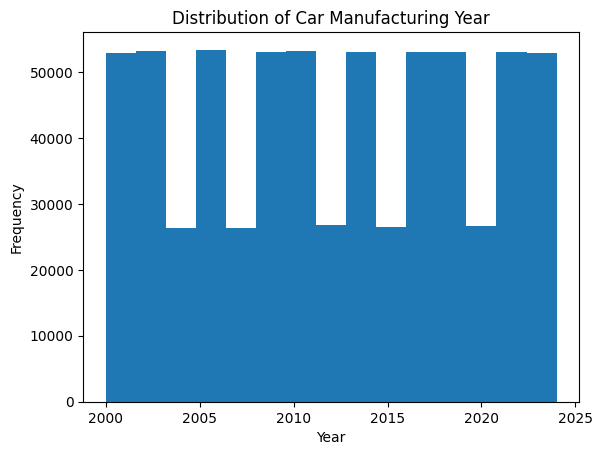

In [ ]:
plt.hist(ds['Year'], bins=15)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Car Manufacturing Year')
plt.show()

In [ ]:
model.predict([[7 ,	10 ,	2011 	,2011.995710, 	890.952794 ,	77.186502 ,	2 	,1 	,2 ,	1 ,	7 	,126798 ,	1 ,	1 ,	0 	,1 ,	4 ,	5 ,	141]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[-2470477.43085582]])

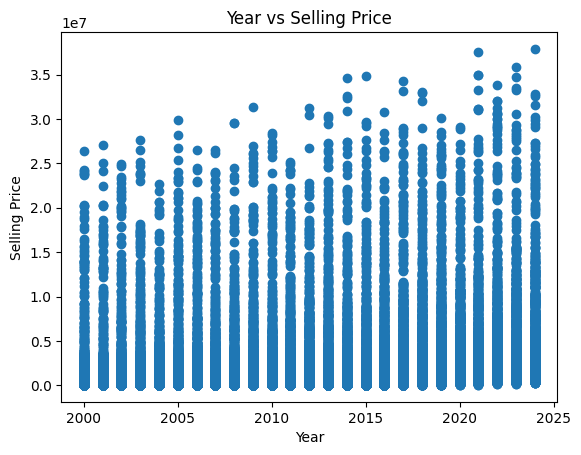

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(ds["Year"], ds["Price"])
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()